### Complete EDA: Sales Dataset

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Dataset**
```python
data = {
    "Product":["A","A","B","B","C","C","D","D","A","B","C","D"],
    "Region":["North","South","North","South","North","South","North","South","West","West","West","West"],
    "Units":[120,150,180,160,90,110,200,220,140,170,100,210],
    "Price":[20,22,18,19,25,24,15,16,21,18,24,15],
    "Discount":[5,10,0,5,10,15,0,5,5,10,5,0],
    "Revenue":[2280,2970,3240,2888,2250,2244,3000,3344,2793,2754,2394,3150]
}
```

**Tasks**
1. Create a visual EDA report using Matplotlib and Seaborn.
2. Compare revenue across products and regions.
3. Visualize units, price, discount and revenue distributions.
4. Create appropriate categorical plots with hue.
5. Create a correlation heatmap for numerical variables.
6. Analyze relationships between discount, units and revenue.
7. Detect possible outliers visually.
8. Write at least five business observations supported by charts.

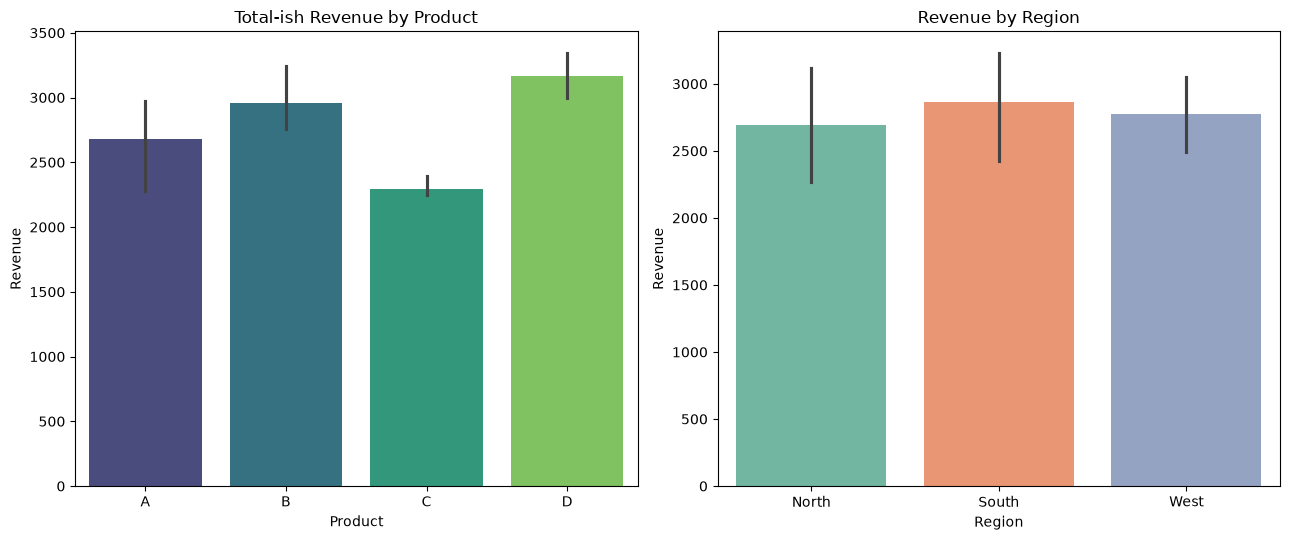

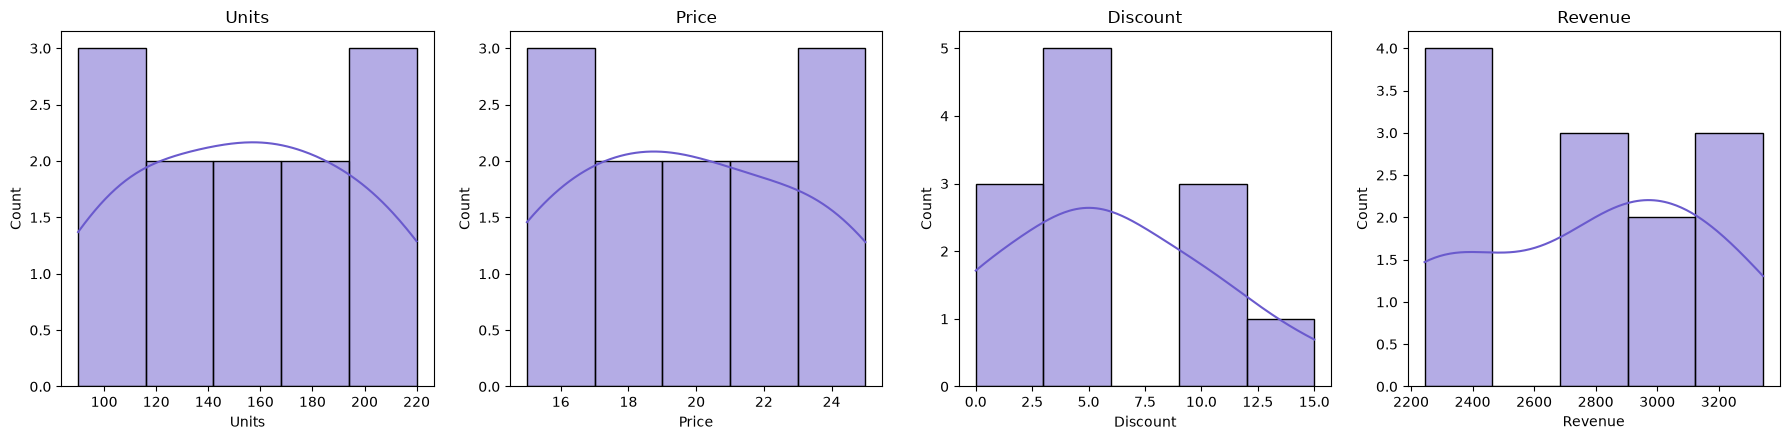

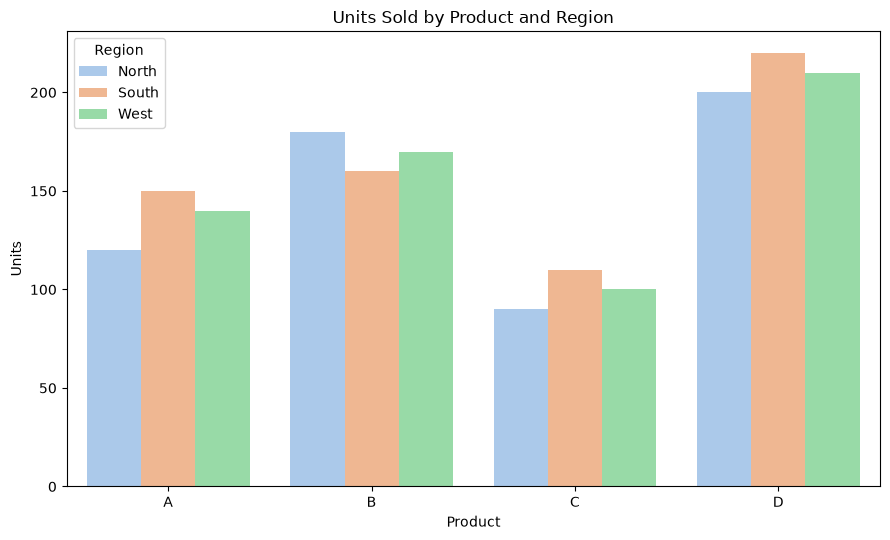

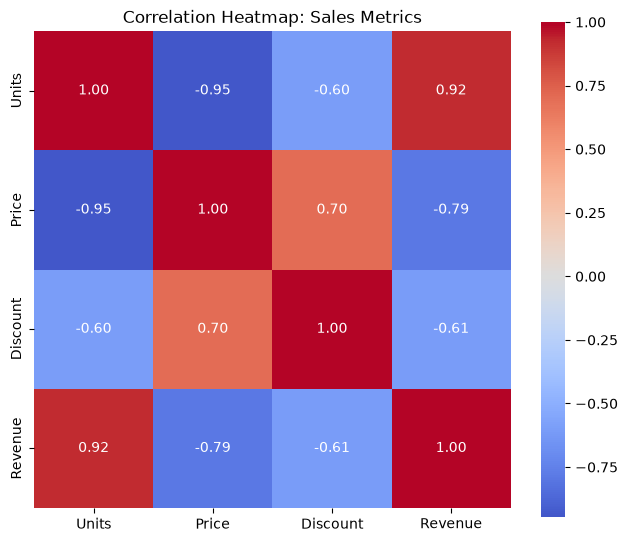

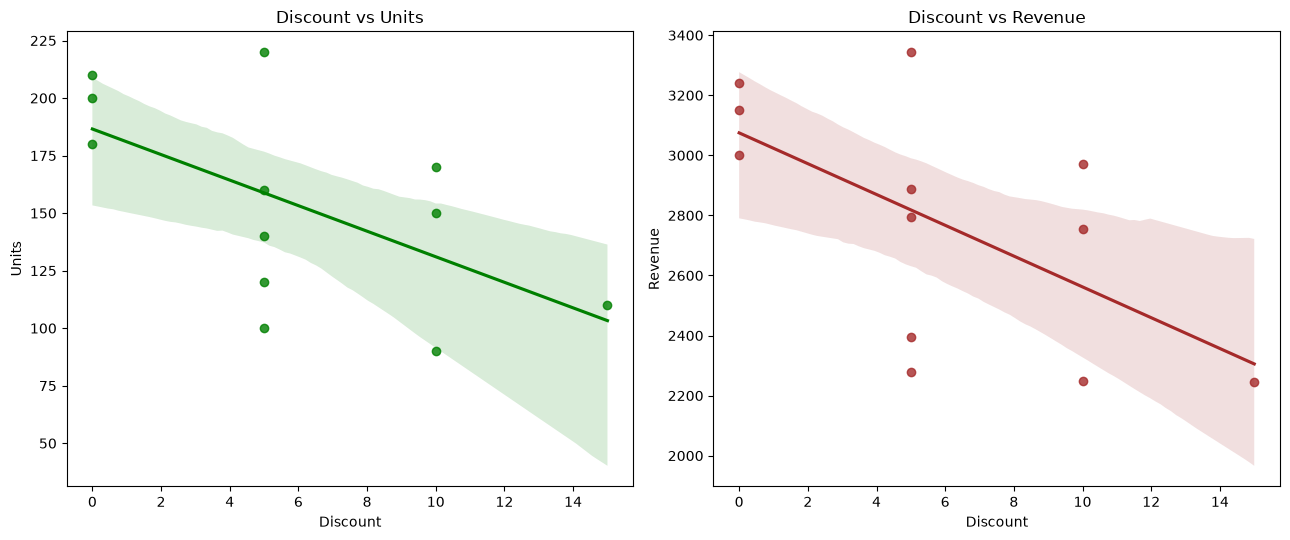

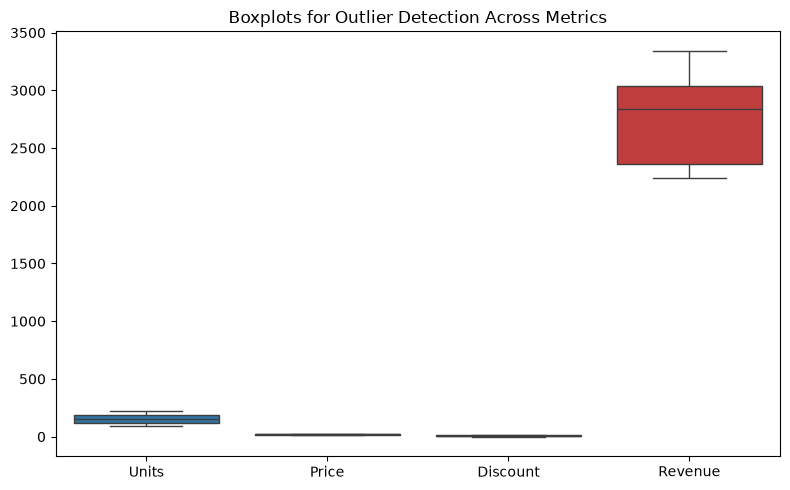

Business observations:
1. Product D generates the highest revenue despite having the lowest price, driven by high
   unit volume.
2. Discount shows a positive relationship with Units sold, suggesting discounting drives volume.
3. Revenue does not increase as strongly with Discount as Units does, implying discounts may
   erode margins even while boosting sales volume.
4. The West region records high revenue with only two products types, worth expanding to more.
5. No extreme outliers are visible in the numerical metrics, so this dataset is comparatively
   clean for further modeling.


In [3]:
data35 = {
    "Product":["A","A","B","B","C","C","D","D","A","B","C","D"],
    "Region":["North","South","North","South","North","South","North","South","West","West","West","West"],
    "Units":[120,150,180,160,90,110,200,220,140,170,100,210],
    "Price":[20,22,18,19,25,24,15,16,21,18,24,15],
    "Discount":[5,10,0,5,10,15,0,5,5,10,5,0],
    "Revenue":[2280,2970,3240,2888,2250,2244,3000,3344,2793,2754,2394,3150]
}
df35 = pd.DataFrame(data35)

# 2. Revenue by product and region
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.barplot(data=df35, x="Product", y="Revenue", hue="Product", palette="viridis",
            legend=False, ax=axes[0])
axes[0].set_title("Total-ish Revenue by Product")
sns.barplot(data=df35, x="Region", y="Revenue", hue="Region", palette="Set2",
            legend=False, ax=axes[1])
axes[1].set_title("Revenue by Region")
plt.tight_layout()
plt.show()

# 3. Distributions
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, ["Units", "Price", "Discount", "Revenue"]):
    sns.histplot(df35[col], kde=True, color='slateblue', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# 4. Categorical plot with hue
plt.figure(figsize=(9, 5.5))
sns.barplot(data=df35, x="Product", y="Units", hue="Region", palette="pastel")
plt.title("Units Sold by Product and Region")
plt.tight_layout()
plt.show()

# 5. Correlation heatmap
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(df35[["Units","Price","Discount","Revenue"]].corr(), annot=True,
            fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap: Sales Metrics")
plt.tight_layout()
plt.show()

# 6. Discount vs Units vs Revenue
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.regplot(data=df35, x="Discount", y="Units", color='green', ax=axes[0])
axes[0].set_title("Discount vs Units")
sns.regplot(data=df35, x="Discount", y="Revenue", color='brown', ax=axes[1])
axes[1].set_title("Discount vs Revenue")
plt.tight_layout()
plt.show()

# 7. Outlier detection
plt.figure(figsize=(8, 5))
sns.boxplot(data=df35[["Units","Price","Discount","Revenue"]])
plt.title("Boxplots for Outlier Detection Across Metrics")
plt.tight_layout()
plt.show()

print('''Business observations:
1. Product D generates the highest revenue despite having the lowest price, driven by high
   unit volume.
2. Discount shows a positive relationship with Units sold, suggesting discounting drives volume.
3. Revenue does not increase as strongly with Discount as Units does, implying discounts may
   erode margins even while boosting sales volume.
4. The West region records high revenue with only two products types, worth expanding to more.
5. No extreme outliers are visible in the numerical metrics, so this dataset is comparatively
   clean for further modeling.''')
